## 9.6. Concise Implementation of RNN

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 9.6.1. Defining the Model

In [2]:
class RNN(d2l.Module):  #@save
    """The RNN model implemented with high-level APIs."""
    def __init__(self, num_inputs, num_hiddens):
        super().__init__()
        self.save_hyperparameters()
        self.rnn = nn.RNN(num_inputs, num_hiddens)

    def forward(self, inputs, H=None):
        return self.rnn(inputs, H)

In [3]:
class RNNLM(d2l.RNNLMScratch):  #@save
    """The RNN-based language model implemented with high-level APIs."""
    def init_params(self):
        self.linear = nn.LazyLinear(self.vocab_size)

    def output_layer(self, hiddens):
        return self.linear(hiddens).swapaxes(0, 1)

In [16]:
x = torch.tensor([[[0,1],[2,3]],[[4,5],[6,7]],[[8,9],[10,11]]])
x.shape, x, x[1, 0, 1]

(torch.Size([3, 2, 2]),
 tensor([[[ 0,  1],
          [ 2,  3]],
 
         [[ 4,  5],
          [ 6,  7]],
 
         [[ 8,  9],
          [10, 11]]]),
 tensor(5))

In [17]:
torch.swapaxes(x, 0, 2).shape, torch.swapaxes(x, 0, 2),  x[1, 0, 1]

(torch.Size([2, 2, 3]),
 tensor([[[ 0,  4,  8],
          [ 2,  6, 10]],
 
         [[ 1,  5,  9],
          [ 3,  7, 11]]]),
 tensor(5))

### 9.6.2. Training and Predicting

In [39]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNN(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
model.predict('it has', 20, data.vocab)

'it hasanytnnytnnytnnytnnyt'

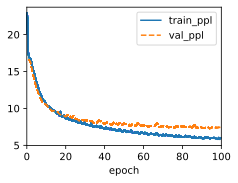

In [40]:
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [58]:
model.predict('you would say', 80, data.vocab, d2l.try_gpu())

'you would say so at and the the time traveller and the time traveller and the time traveller '

### 9.6.4. Exercises

In [59]:
from torchinfo import summary

In [65]:
summary(model)

Layer (type:depth-idx)                   Param #
RNNLM                                    --
├─RNN: 1-1                               --
│    └─RNN: 2-1                          1,984
├─Linear: 1-2                            924
Total params: 2,908
Trainable params: 2,908
Non-trainable params: 0

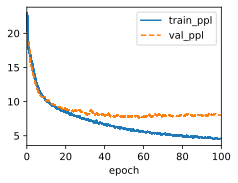

In [66]:
data = d2l.TimeMachine(batch_size=1024, num_steps=64)
rnn = RNN(num_inputs=len(data.vocab), num_hiddens=64)
model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [67]:
model.predict('you would say', 80, data.vocab, d2l.try_gpu())

'you would say us the time traveller coun a cont of the three dimension of the time traveller '

### Autoregressive model (at least tried)

In [71]:
class RNNModel(d2l.Classifier):
    def __init__(self, vocab_size, num_hiddens, lr=0.01, sigma=0.01, autoregressive=False):
        super().__init__()
        self.save_hyperparameters()

        self.W_xh = nn.Parameter(torch.randn(vocab_size, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens) * sigma)
        self.W_hq = nn.Parameter(torch.randn(num_hiddens, vocab_size) * sigma)
        self.b_h  = nn.Parameter(torch.zeros(num_hiddens))
        self.b_q  = nn.Parameter(torch.zeros(vocab_size))

    def step(self, x_onehot, H):
        H = torch.tanh(x_onehot @ self.W_xh + H @ self.W_hh + self.b_h)
        y = H @ self.W_hq + self.b_q
        return y, H

    def forward(self, X, state=None):
        batch_size, num_steps = X.shape
        H = torch.zeros(batch_size, self.num_hiddens, device=X.device) if state is None else state

        X_onehot = F.one_hot(X, self.vocab_size).float()
        logits_list = []

        if not self.autoregressive:
            for t in range(num_steps):
                y_t, H = self.step(X_onehot[:, t, :], H)
                logits_list.append(y_t)
        else:
            y_t, H = self.step(X_onehot[:, 0, :], H)
            logits_list.append(y_t)
            for _ in range(1, num_steps):
                x_t = F.one_hot(y_t.argmax(dim=-1), self.vocab_size).float()
                y_t, H = self.step(x_t, H)
                logits_list.append(y_t)

        return torch.stack(logits_list, dim=1)

    def training_step(self, batch):
        X, Y = batch[0], batch[1]
        logits = self.forward(X)
        l = self.loss(logits.reshape(-1, self.vocab_size), Y.reshape(-1))
        self.plot('ppl', torch.exp(l), train=True)
        return l

    def validation_step(self, batch):
        X, Y = batch[0], batch[1]
        logits = self.forward(X)
        l = self.loss(logits.reshape(-1, self.vocab_size),Y.reshape(-1))
        self.plot('ppl', torch.exp(l), train=False)

    def predict(self, prefix, num_preds, vocab, device=None):
        self.eval()
        H = torch.zeros(1, self.num_hiddens, device=device)
        outputs = [vocab[prefix[0]]]

        with torch.no_grad():
            for i in range(len(prefix) - 1):
                x_t = F.one_hot(torch.tensor([outputs[-1]], device=device), self.vocab_size).float()
                _, H = self.step(x_t, H)
                outputs.append(vocab[prefix[i + 1]])

            x_t = F.one_hot(torch.tensor([outputs[-1]], device=device), self.vocab_size).float()
            for _ in range(num_preds):
                y_t, H = self.step(x_t, H)
                next_token = int(y_t.argmax(dim=-1))
                outputs.append(next_token)
                x_t = F.one_hot(torch.tensor([next_token], device=device), self.vocab_size).float()
        return ''.join([vocab.idx_to_token[i] for i in outputs])

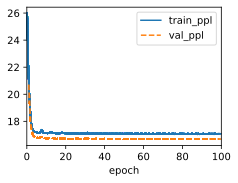

In [72]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
model = RNNModel(vocab_size=len(data.vocab), num_hiddens=32, lr=1, autoregressive=True)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [76]:
model.predict('it', 80, data.vocab, d2l.try_gpu())

'it                                                                                '